# Exercise 1:
- Hãy hoàn thiện hàm compute_vector_length() để tính độ dài của vector sử dụng
thư viện numpy:

In [222]:
import numpy as np

In [223]:
#version 1
def compute_vector_length1 ( vector ) :
    # *********** Your code here ***********
    len_of_vector = np.sqrt(np.sum([v ** 2 for v in vector]))
    return len_of_vector

vector = np.array([-2, 4, 9, 21])
res = compute_vector_length1([vector])
print(round(res, 2))

23.28


In [224]:
#ver 2
def compute_vector_length2(vector):
    res = np.linalg.norm(vector)
    return res
vector = np.array([-2, 4, 9, 21])
res = compute_vector_length2([vector])
print(round(res, 2))

23.28


In [225]:
def compute_dot_product(v1, v2):
    res = np.dot(v1, v2)
    return res

# Test case 1
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])
assert compute_dot_product(v1, v2) == 32

# Test case 2 (dùng biến vector đã có sẵn trong notebook)
assert compute_dot_product(vector, vector) == 542

print("All test cases passed.")


All test cases passed.


In [226]:
def matrix_multi_vector(matrix, vector):
    res = np.dot(matrix, vector)
    return res
# Test case for matrix-vector multiplication
matrix = np.array([
    [1, 0, 2, -1],
    [3, 4, 0, 2]
])

expected = np.array([-5, 52])
result = matrix_multi_vector(matrix, vector)

assert np.array_equal(result, expected)
print("Matrix-vector multiplication test passed.")


Matrix-vector multiplication test passed.


In [227]:
def matrix_multi_multi(matrix1, matrix2):
    return np.dot(matrix1, matrix2)

matrix1 = np.array([
    [1, 0, 2, -1],
    [3, 4, 0, 2]
])

matrix2 = np.array([
    [1, 2],
    [0, 1],
    [3, 0],
    [2, -1]
])

expected = np.array([
    [5, 3],
    [7, 8]
])

result = matrix_multi_multi(matrix1, matrix2)

assert np.array_equal(result, expected)
print("Matrix-matrix multiplication test passed.")


Matrix-matrix multiplication test passed.


In [228]:
def inverse_matrix(matrix):
    return np.linalg.inv(matrix)

# Test case for inverse_matrix
matrix_test = np.array([[1, 2], [3, 4]])
expected_inverse = np.linalg.inv(matrix_test)

result = inverse_matrix(matrix_test)

assert np.allclose(result, expected_inverse), "inverse_matrix test failed"
print("inverse_matrix test passed.")


inverse_matrix test passed.


# Exercise 2

In [229]:
def compute_eigenvalues_eigenvectors(matrix):
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    return eigenvalues, eigenvectors
    # Test case for eigenvalues and eigenvectors
    matrix_test = np.array([0.9, 0.2], [0.1, 0.8])
    eigenvalues, eigenvectors = compute_eigenvalues_eigenvectors(matrix_test)
    print("Eigenvalues:", eigenvalues)
    print("Eigenvectors:\n", eigenvectors)

    # Verify: A * v = lambda * v
    for i in range(len(eigenvalues)):
        Av = np.dot(matrix_test, eigenvectors[:, i])
        lambda_v = eigenvalues[i] * eigenvectors[:, i]
        assert np.allclose(Av, lambda_v), f"Eigenvalue {i} test failed"

    print("Eigenvalues and eigenvectors test passed.")

# Exercise 3

In [230]:
from numpy import dot
from numpy.linalg import norm

def comput_cosin(v1, v2):
    res = compute_dot_product(v1, v2) / (compute_vector_length2(v1) * compute_vector_length2(v2))
    return res
x = np.array([1, 2, 3, 4])
y = np.array([1, 0, 3, 0])
res = comput_cosin(x, y)
print(round(res, 3))


0.577


# Exercise 4

In [231]:
import cv2
green_bg = cv2.imread('GreenBackground.png')
green_bg = cv2.resize(green_bg, (678, 381))

ob_img = cv2.imread('Object.png')
ob_img = cv2.resize(ob_img, (678, 381))

new_bg = cv2.imread('NewBackground.jpg')
new_bg = cv2.resize(new_bg, (678, 381))

In [232]:
def compute_diff(bg_img, input_img):
    diff_three_channel = cv2.absdiff(bg_img, input_img)
    diff_single_channel = np.sum(diff_three_channel, axis=2) / 3.0
    diff_single_channel = diff_single_channel.astype('uint8')
    return diff_single_channel

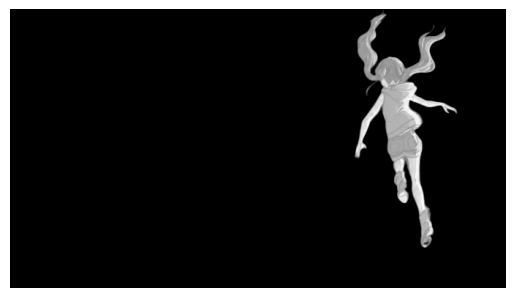

In [233]:
diff_single_channel = compute_diff(green_bg, ob_img)

import matplotlib.pyplot as plt

plt.imshow(diff_single_channel, cmap='gray')
plt.axis('off')

plt.show()

In [234]:
def compute_Binary_Mask(diff_single_channel):
    diff_binary = np.where(diff_single_channel >= 15, 255, 0)
    diff_binary = np.stack((diff_binary,) * 3, axis=-1)
    return diff_binary

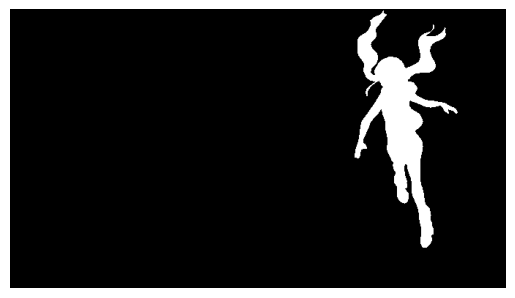

In [235]:
binary_mask = compute_Binary_Mask(diff_single_channel)
plt.imshow(binary_mask, cmap = 'gray')
plt.axis('off')

plt.show()

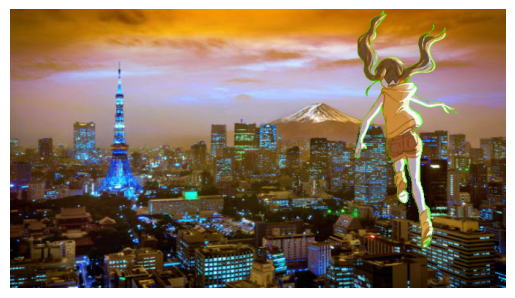

In [236]:
def replaceBg(bg1, bg2, ob):
    diff_single_channel = compute_diff(bg1, ob)
    binary_mask = compute_Binary_Mask(diff_single_channel)
    res = np.where(binary_mask==255, ob, bg2)
    return res
res = replaceBg(green_bg, new_bg, ob_img)

plt.imshow(res)
plt.axis('off')

plt.show()